The problem is that analysing multiple water-quality measurements manually can make it difficult to quickly determine the pollution level of water. This project aims to use machine learning classification models to analyse water-quality data and predict pollution levels, helping to identify which model provides the most reliable predictions.

Another problem is that pollution levels are usually only found out after a reading has already been taken, which means action can only be taken after the fact. This project also uses machine learning to look at past water-quality readings and forecast what the pollution level is likely to be next, so that problems can be picked up earlier instead of only after they happen.

Importing Pandas to be able to read the cvs file
Importing matplotlib to plot graphs
Importing seaborn to assist matplotlib to make it look neater

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('Water_Quality_Dataset.csv')
print(df.shape)

(1000, 11)


df head prints out the first 5 rows of the data

In [2]:
df.head()

,Timestamp,Location,pH,Turbidity (NTU),Temperature (°C),DO (mg/L),BOD (mg/L),Lead (mg/L),Mercury (mg/L),Arsenic (mg/L),Pollution_Level
0,2024-01-01 00:00:00,L4,8.762414,14.468306,16.461631,6.258335,2.478582,0.002801,0.001924,0.018769,2
1,2024-01-01 01:00:00,L5,7.477966,1.905645,27.446865,2.826120,8.048453,0.019551,0.000633,0.003708,2
2,2024-01-01 02:00:00,L3,7.938278,1.889506,34.623557,3.380191,2.102481,0.019291,0.000205,0.005055,2
3,2024-01-01 03:00:00,L5,8.728748,0.736115,18.802153,6.543794,6.714160,0.003358,0.001058,0.005638,2
4,2024-01-01 04:00:00,L5,7.975335,19.151777,30.851902,4.370861,2.114614,0.006059,0.000124,0.001237,2


Shows us the data structure

observations: We can see that there are 1000 records in the table with their data types 

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Timestamp         1000 non-null   str    
 1   Location          1000 non-null   str    
 2   pH                1000 non-null   float64
 3   Turbidity (NTU)   1000 non-null   float64
 4   Temperature (°C)  1000 non-null   float64
 5   DO (mg/L)         1000 non-null   float64
 6   BOD (mg/L)        1000 non-null   float64
 7   Lead (mg/L)       1000 non-null   float64
 8   Mercury (mg/L)    1000 non-null   float64
 9   Arsenic (mg/L)    1000 non-null   float64
 10  Pollution_Level   1000 non-null   int64  
dtypes: float64(8), int64(1), str(2)
memory usage: 106.6 KB


Calculating and giving us the summary of the numerical values

Observations: Here we notice that Pollution level 2 has a larger number compare to the other records

In [4]:
df.describe()

,pH,Turbidity (NTU),Temperature (°C),DO (mg/L),BOD (mg/L),Lead (mg/L),Mercury (mg/L),Arsenic (mg/L),Pollution_Level
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,7.250855,10.218681,24.966871,5.928647,5.482985,0.009965,0.000981,0.009855,1.909000
std,1.024515,5.631584,5.756625,2.287483,2.604094,0.005746,0.000569,0.005544,0.307919
min,5.516212,0.502627,15.000233,2.000246,1.008491,0.000128,0.000010,0.000505,0.000000
25%,6.324944,5.566377,19.950098,3.984953,3.242944,0.005000,0.000489,0.005015,2.000000
50%,7.265239,10.236904,25.041492,5.871292,5.368891,0.009894,0.000977,0.009392,2.000000
75%,8.107655,15.148932,29.967260,7.841829,7.730134,0.015130,0.001444,0.014484,2.000000
max,8.997948,19.967776,34.991154,9.981995,9.994153,0.019989,0.001998,0.019922,2.000000


Check the number of different value counts for pollution

Observation: We notice that theres a huge difference within Pollution level, so we fix that

In [5]:
df["Pollution_Level"].value_counts()

Pollution_Level
2    915
1     79
0      6
Name: count, dtype: int64

In [6]:
# Collapse Level 0 into Level 1: 0 -> "Not Polluted", 2 stays "Polluted"
df["Pollution_Level_Binary"] = df["Pollution_Level"].replace({0: 1})

print(df["Pollution_Level_Binary"].value_counts())

Pollution_Level_Binary
2    915
1     85
Name: count, dtype: int64


In [7]:
counts = df["Pollution_Level_Binary"].value_counts().sort_index()
percentages =df["Pollution_Level_Binary"].value_counts(normalize=True).sort_index() * 100
summary = pd.DataFrame({
    "Count": counts,
    "Percentage": percentages.round(2)
})
print(summary)

                        Count  Percentage
Pollution_Level_Binary                   
1                          85         8.5
2                         915        91.5


In [8]:
# Map: old level 1 (collapsed 0+1) -> 0, old level 2 -> 1
df["Pollution_Level_Binary"] = df["Pollution_Level"].replace({0: 1, 1: 0, 2: 1})
df = df.drop(columns=["Pollution_Level"])
df = df.rename(columns={"Pollution_Level_Binary": "Pollution_Level"})
df["Pollution_Level"].value_counts()

Pollution_Level
1    921
0     79
Name: count, dtype: int64

Checking for nun-null values

Observations: We can see that there are no null values in the dataset 

In [9]:
df.isnull().sum()

Timestamp           0
Location            0
pH                  0
Turbidity (NTU)     0
Temperature (°C)    0
DO (mg/L)           0
BOD (mg/L)          0
Lead (mg/L)         0
Mercury (mg/L)      0
Arsenic (mg/L)      0
Pollution_Level     0
dtype: int64

Checking for duplicates

In [10]:
print(df.duplicated().sum())

0


Checks how many times a value appears ina column

Observations:
We see that the count for the different locations are rather similar so its not like one location is being neglected

In [11]:
df["Location"].value_counts()

Location
L1    210
L4    206
L5    204
L3    190
L2    190
Name: count, dtype: int64

Checking how many records of each pollution level there is 

Checks how many records exist for each location in abar graph form

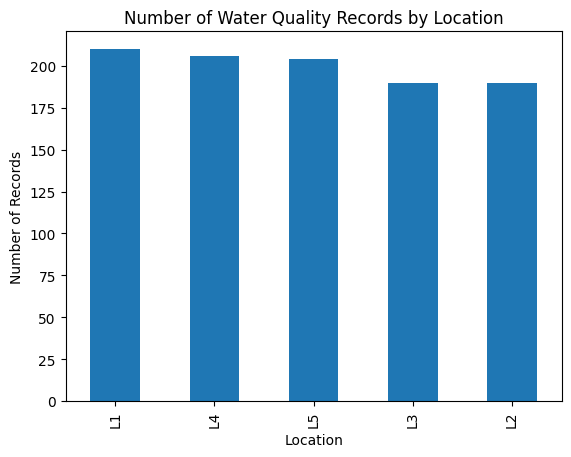

In [12]:
df["Location"].value_counts().plot(kind="bar")

plt.title("Number of Water Quality Records by Location")
plt.xlabel("Location")
plt.ylabel("Number of Records")
plt.show()

The occurance of each unique value in the form of a bar graph

Observations:
Here we can see that Polution level in level 0 (Polutted) is heavily dominating in count

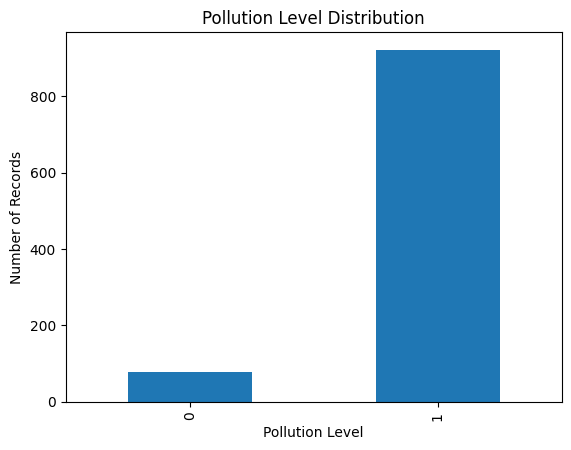

In [13]:
df["Pollution_Level"].value_counts().sort_index().plot(kind="bar")

plt.title("Pollution Level Distribution")
plt.xlabel("Pollution Level")
plt.ylabel("Number of Records")
plt.show()

In [14]:
for column in df.select_dtypes(include="number").columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ]

    print(column)
    print("Number of outliers:", len(outliers))
    print()

pH
Number of outliers: 0

Turbidity (NTU)
Number of outliers: 0

Temperature (°C)
Number of outliers: 0

DO (mg/L)
Number of outliers: 0

BOD (mg/L)
Number of outliers: 0

Lead (mg/L)
Number of outliers: 0

Mercury (mg/L)
Number of outliers: 0

Arsenic (mg/L)
Number of outliers: 0

Pollution_Level
Number of outliers: 79



This creates a set of boxplots, one for each listed column, so you can compare their distributions.

Observation:There was no serious observation that caused us to change something 

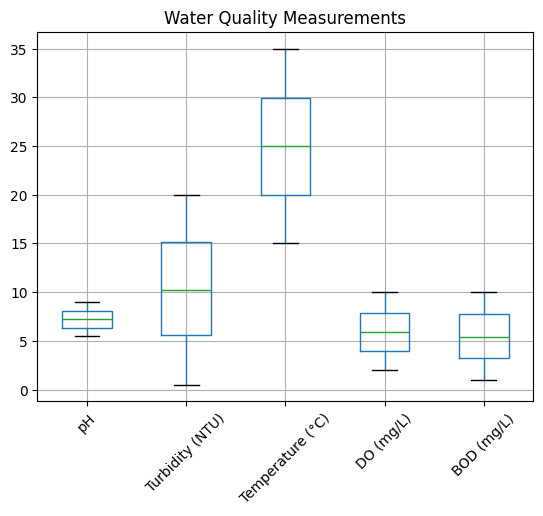

In [15]:
df.boxplot(
    column=[
        "pH",
        "Turbidity (NTU)",
        "Temperature (°C)",
        "DO (mg/L)",
        "BOD (mg/L)"
    ]
)

plt.xticks(rotation=45)
plt.title("Water Quality Measurements")
plt.show()

Groups the data by location and gives the average for each listed location

Observations: 
We notice that all values are relatively similar in each location so once again, there is no location that is heavily different

In [16]:
df.groupby("Location")[
    ["pH", "Turbidity (NTU)", "Temperature (°C)",
     "DO (mg/L)", "BOD (mg/L)"]
].mean()

,pH,Turbidity (NTU),Temperature (°C),DO (mg/L),BOD (mg/L)
Location,,,,,
L1,7.191603,10.302628,25.507970,5.953713,5.649244
L2,7.311730,10.884517,25.381239,5.908332,5.598476
L3,7.204735,9.133566,24.816292,5.854478,5.258485
L4,7.324825,9.875058,24.287666,5.852014,5.529789
L5,7.223412,10.869760,24.850037,6.068231,5.366100


Checking for the pollution level at each location

In [17]:
pd.crosstab(df["Location"], df["Pollution_Level"])

Pollution_Level,0,1
Location,,
L1,11,199
L2,15,175
L3,18,172
L4,20,186
L5,15,189


Plotting a heatmap to see the correlation between all the attributes in the dataset

Observation: Turbidity has the highest correlation for determining the Pollution_Level (Which is our target attribute) so it will be the one that we're leaning towards the most

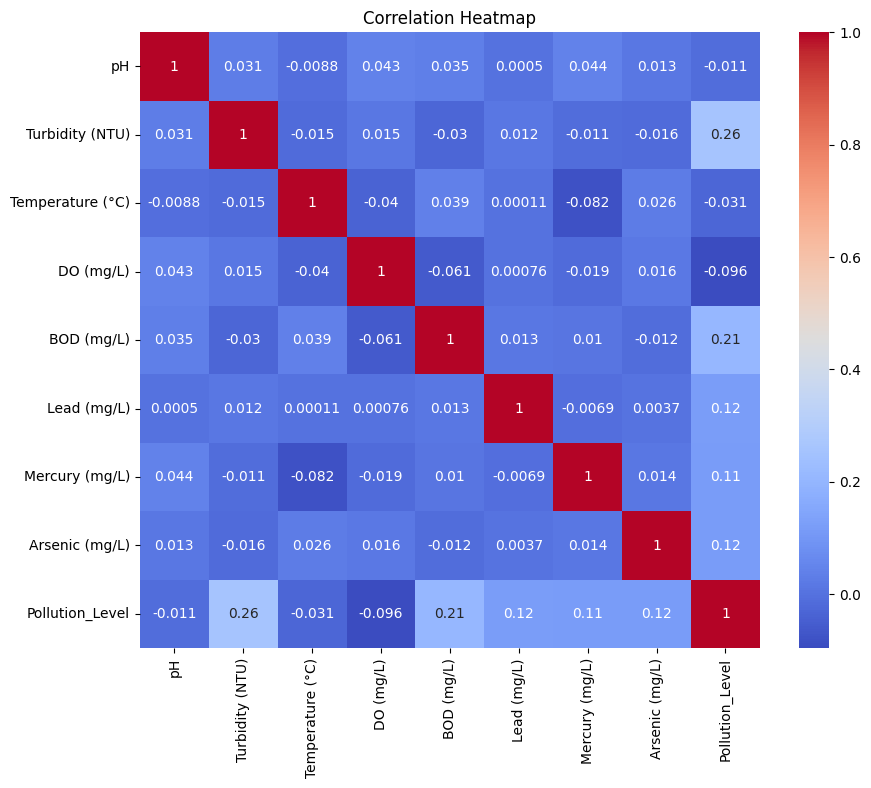

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

The correlation between the pollution level and the attributes

In [19]:
df.select_dtypes(include="number").corr()["Pollution_Level"].sort_values()

DO (mg/L)          -0.096466
Temperature (°C)   -0.030731
pH                 -0.011113
Mercury (mg/L)      0.114174
Arsenic (mg/L)      0.115272
Lead (mg/L)         0.118755
BOD (mg/L)          0.206966
Turbidity (NTU)     0.255792
Pollution_Level     1.000000
Name: Pollution_Level, dtype: float64

Plotting a scatter plot to see the correlation between the pollution level and the turbidity

Observations:
We can see that distinctly that there are clear values where pollution level of 2 is gurranteed and when pollution level of 0 and 1 stops

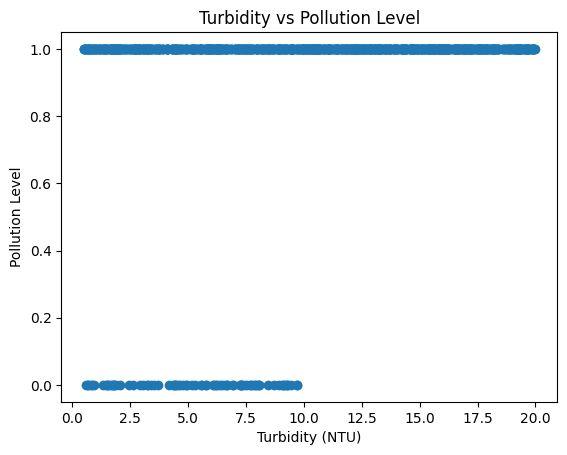

In [20]:
plt.scatter(
    df["Turbidity (NTU)"],
    df["Pollution_Level"]
)

plt.title("Turbidity vs Pollution Level")
plt.xlabel("Turbidity (NTU)")
plt.ylabel("Pollution Level")
plt.show()

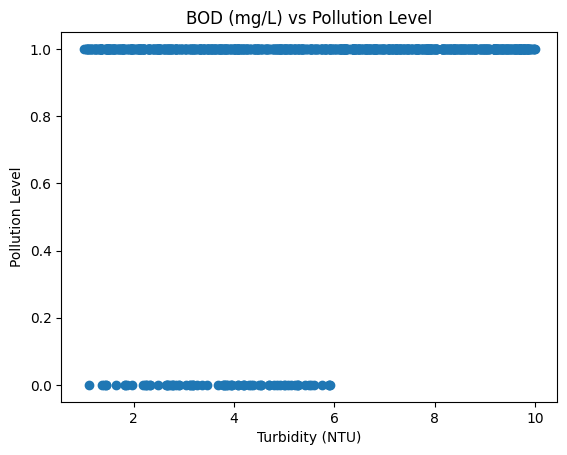

In [21]:
plt.scatter(
    df["BOD (mg/L)"],
    df["Pollution_Level"]
)

plt.title("BOD (mg/L) vs Pollution Level")
plt.xlabel("Turbidity (NTU)")
plt.ylabel("Pollution Level")
plt.show()

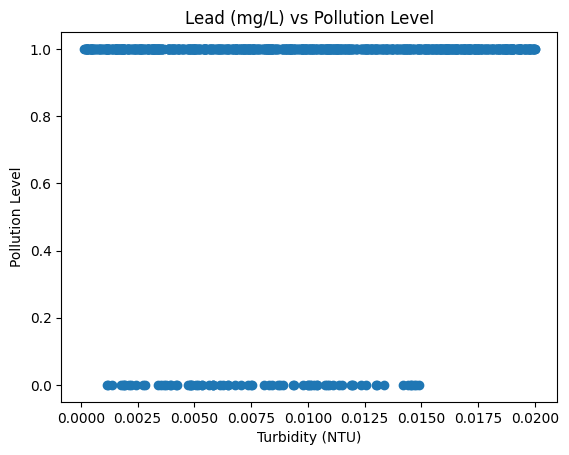

In [22]:
plt.scatter(
    df["Lead (mg/L)"],
    df["Pollution_Level"]
)

plt.title("Lead (mg/L) vs Pollution Level")
plt.xlabel("Turbidity (NTU)")
plt.ylabel("Pollution Level")
plt.show()

Pollution level is the target attribute

In [23]:
y = df["Pollution_Level"]

Pollution is dependent on the following attributes

In [24]:
X = df[
    [
        "pH",
        "Turbidity (NTU)",
        "Temperature (°C)",
        "DO (mg/L)",
        "BOD (mg/L)",
        "Lead (mg/L)",
        "Mercury (mg/L)",
        "Arsenic (mg/L)"
    ]
]

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,ConfusionMatrixDisplay

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
y_test.value_counts()

Pollution_Level
1    184
0     16
Name: count, dtype: int64

Using smote to test to see if oversampling is going to work 

In [26]:
# pip install imbalanced-learn (if not already installed)
from imblearn.over_sampling import SMOTE
from collections import Counter

# Check how many samples of each class are in the training set
print("Before SMOTE:", Counter(y_train))

# SMOTE needs k_neighbors < number of samples in the smallest class.
# Auto-adjust k_neighbors so it never exceeds (min_class_count - 1)
min_class_count = min(Counter(y_train).values())
k = min(5, max(1, min_class_count - 1))

smote = SMOTE(random_state=42, k_neighbors=k)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("After SMOTE:", Counter(y_train_sm))

Before SMOTE: Counter({1: 737, 0: 63})
After SMOTE: Counter({1: 737, 0: 737})


From this point onwards, we are going to be testing some models to see how accurate they are in determining the Pollution level based off the features of X before we start with Forecasting

Testing the random forest model

In [27]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced" 
)

model_rf.fit(X_train_sm, y_train_sm)

prediction_rf = model_rf.predict(X_test)

train_accuracy = model_rf.score(X_train_sm, y_train_sm) * 100
test_accuracy = model_rf.score(X_test, y_test) * 100
print(f"Training accuracy: {train_accuracy:.2f}%")
print(f"Test accuracy: {test_accuracy:.2f}%")
print(f"Gap: {train_accuracy - test_accuracy:.2f}%")

print(classification_report(y_test, prediction_rf))

from sklearn.inspection import permutation_importance
result = permutation_importance(model_rf, X_test, y_test, n_repeats=10, random_state=42, scoring="f1")
importance_df = pd.DataFrame({"Feature": X.columns, "Importance": result.importances_mean}).sort_values("Importance", ascending=False)
print(importance_df)

Training accuracy: 100.00%
Test accuracy: 96.00%
Gap: 4.00%
              precision    recall  f1-score   support

           0       0.83      0.62      0.71        16
           1       0.97      0.99      0.98       184

    accuracy                           0.96       200
   macro avg       0.90      0.81      0.85       200
weighted avg       0.96      0.96      0.96       200

            Feature  Importance
1   Turbidity (NTU)    0.038839
4        BOD (mg/L)    0.033399
6    Mercury (mg/L)    0.013921
5       Lead (mg/L)    0.010958
7    Arsenic (mg/L)    0.009083
0                pH    0.004024
3         DO (mg/L)    0.001896
2  Temperature (°C)   -0.001846


Importing the XGBoost and classification report

In [28]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)
model.fit(X_train_sm, y_train_sm)
y_pred = model.predict(X_test)

train_accuracy = model.score(X_train_sm, y_train_sm) * 100
test_accuracy = model.score(X_test, y_test) * 100
print(f"Training accuracy: {train_accuracy:.2f}%")
print(f"Test accuracy: {test_accuracy:.2f}%")

print(classification_report(y_test, y_pred))


from sklearn.inspection import permutation_importance
result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, scoring="f1")
importance_df = pd.DataFrame({"Feature": X.columns, "Importance": result.importances_mean}).sort_values("Importance", ascending=False)
print(importance_df)

Training accuracy: 99.80%
Test accuracy: 97.00%
              precision    recall  f1-score   support

           0       0.86      0.75      0.80        16
           1       0.98      0.99      0.98       184

    accuracy                           0.97       200
   macro avg       0.92      0.87      0.89       200
weighted avg       0.97      0.97      0.97       200

            Feature  Importance
1   Turbidity (NTU)    0.045709
4        BOD (mg/L)    0.039863
6    Mercury (mg/L)    0.024932
5       Lead (mg/L)    0.014022
7    Arsenic (mg/L)    0.012117
0                pH    0.004850
3         DO (mg/L)    0.001370
2  Temperature (°C)    0.000060


In [30]:


model = DecisionTreeClassifier(random_state=42,class_weight="balanced")

model.fit(X_train_sm, y_train_sm)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.62      0.69        16
           1       0.97      0.98      0.98       184

    accuracy                           0.95       200
   macro avg       0.87      0.80      0.83       200
weighted avg       0.95      0.95      0.95       200



~Logistic regression model to test~

In [31]:
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression(max_iter=1000)

model_lr.fit(X_train_sm, y_train_sm)

prediction_lr = model_lr.predict(X_test)

accuracy_lr = accuracy_score(y_test, prediction_lr)

print(classification_report(y_test, prediction_lr))

              precision    recall  f1-score   support

           0       0.20      0.62      0.30        16
           1       0.96      0.78      0.86       184

    accuracy                           0.77       200
   macro avg       0.58      0.70      0.58       200
weighted avg       0.90      0.77      0.81       200



~**Forecasting**~

Here we converting the date from String to Date Dtype

In [32]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

Here we are sorting the values by ascending order based on location and timestamp.

Then we create lag_cols which is going to store the names of our columns only

In the for loop, we are creating "lag" columns which will hold the previous value of that specific column.

Crucially grouping by location so that we don't accidently take the readings of another column.

In [33]:
df = df.sort_values(["Location", "Timestamp"]).reset_index(drop=True)
lag_cols = [
    "pH", "Turbidity (NTU)", "Temperature (°C)", "DO (mg/L)",
    "BOD (mg/L)", "Lead (mg/L)", "Mercury (mg/L)", "Arsenic (mg/L)",
    "Pollution_Level"
]
for col in lag_cols:
    df[f"{col}_lag1"] = df.groupby("Location")[col].shift(1)
df.head()

,Timestamp,Location,pH,Turbidity (NTU),Temperature (°C),DO (mg/L),BOD (mg/L),Lead (mg/L),Mercury (mg/L),Arsenic (mg/L),Pollution_Level,pH_lag1,Turbidity (NTU)_lag1,Temperature (°C)_lag1,DO (mg/L)_lag1,BOD (mg/L)_lag1,Lead (mg/L)_lag1,Mercury (mg/L)_lag1,Arsenic (mg/L)_lag1,Pollution_Level_lag1
0,2024-01-01 18:00:00,L1,8.544637,2.102348,26.301706,4.022865,7.924983,0.001494,0.000960,0.004983,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01-01 23:00:00,L1,6.673190,7.947823,22.140587,5.818803,2.792977,0.009985,0.001422,0.011553,0,8.544637,2.102348,26.301706,4.022865,7.924983,0.001494,0.000960,0.004983,1.0
2,2024-01-02 00:00:00,L1,8.309987,4.510902,33.523881,4.806553,3.557659,0.016875,0.000970,0.007411,1,6.673190,7.947823,22.140587,5.818803,2.792977,0.009985,0.001422,0.011553,0.0
3,2024-01-02 09:00:00,L1,7.082763,6.210030,15.583395,3.769910,5.530106,0.010743,0.000816,0.002354,0,8.309987,4.510902,33.523881,4.806553,3.557659,0.016875,0.000970,0.007411,1.0
4,2024-01-02 14:00:00,L1,7.244287,16.329511,22.956733,5.672992,5.923408,0.015948,0.001809,0.003587,1,7.082763,6.210030,15.583395,3.769910,5.530106,0.010743,0.000816,0.002354,0.0


We are looping through the "lag_cols" array again but this time we stop before "Pollution_Level"

Grouping by location to prevent leaking different locations

Then here we are looking at 3 values of a column at a time then only taking the mean of those values to create our roll3 value

In [34]:
for col in lag_cols[:-1]:
    df[f"{col}_roll3"] = (
        df.groupby("Location")[col]
          .transform(lambda s: s.shift(1).rolling(3).mean())
    )

Creating an hour column and day of the week column which will be used when modeling as a feature

In [35]:
df["hour"] = df["Timestamp"].dt.hour
df["dayofweek"] = df["Timestamp"].dt.dayofweek

Drop any row that has missing roll3 values, because it won't be used for modeling 

Then we getting how much rows we actually dropped 

In [36]:
df_fc = df.dropna().reset_index(drop=True)
print("Rows before dropping first-per-location readings:", len(df))
print("Rows available for forecasting model:", len(df_fc))
df_fc.head()

Rows before dropping first-per-location readings: 1000
Rows available for forecasting model: 985


,Timestamp,Location,pH,Turbidity (NTU),Temperature (°C),DO (mg/L),BOD (mg/L),Lead (mg/L),Mercury (mg/L),Arsenic (mg/L),...,pH_roll3,Turbidity (NTU)_roll3,Temperature (°C)_roll3,DO (mg/L)_roll3,BOD (mg/L)_roll3,Lead (mg/L)_roll3,Mercury (mg/L)_roll3,Arsenic (mg/L)_roll3,hour,dayofweek
0,2024-01-02 09:00:00,L1,7.082763,6.210030,15.583395,3.769910,5.530106,0.010743,0.000816,0.002354,...,7.842605,4.853691,27.322058,4.882740,4.758540,0.009451,0.001117,0.007982,9,1
1,2024-01-02 14:00:00,L1,7.244287,16.329511,22.956733,5.672992,5.923408,0.015948,0.001809,0.003587,...,7.355313,6.222918,23.749288,4.798422,3.960247,0.012534,0.001069,0.007106,14,1
2,2024-01-02 17:00:00,L1,6.768379,7.096216,15.898226,2.949150,4.721649,0.008278,0.001242,0.013991,...,7.545679,9.016814,24.021336,4.749818,5.003724,0.014522,0.001198,0.004450,17,1
3,2024-01-02 21:00:00,L1,7.822381,8.925499,30.085299,2.261272,9.582693,0.002972,0.000342,0.009070,...,7.031810,9.878586,18.146118,4.130684,5.391721,0.011656,0.001289,0.006644,21,1
4,2024-01-03 07:00:00,L1,8.124862,16.410965,19.807978,2.930868,4.434548,0.019199,0.001864,0.014111,...,7.278349,10.783742,22.980086,3.627805,6.742583,0.009066,0.001131,0.008883,7,2


In [37]:
y_fc = df_fc["Pollution_Level"]
X_fc = df_fc.drop(columns=[
    "Timestamp",
    "Location",
    "Pollution_Level",
    "pH",
    "Turbidity (NTU)",
    "Temperature (°C)",
    "DO (mg/L)",
    "BOD (mg/L)",
    "Lead (mg/L)",
    "Mercury (mg/L)",
    "Arsenic (mg/L)"
])
cutoff = df_fc["Timestamp"].quantile(0.8)
train_mask = df_fc["Timestamp"] <= cutoff

X_train_fc, X_test_fc = X_fc[train_mask], X_fc[~train_mask]
y_train_fc, y_test_fc = y_fc[train_mask], y_fc[~train_mask]

print("Train size:", len(X_train_fc), " Test size:", len(X_test_fc))

Train size: 788  Test size: 197


In [38]:
print("Before SMOTE:", Counter(y_train_fc))

min_class_count = min(Counter(y_train_fc).values())
k = min(5, max(1, min_class_count - 1))

smote_fc = SMOTE(random_state=42, k_neighbors=k)
X_train_fc_sm, y_train_fc_sm = smote_fc.fit_resample(X_train_fc, y_train_fc)

print("After SMOTE:", Counter(y_train_fc_sm))

Before SMOTE: Counter({1: 727, 0: 61})
After SMOTE: Counter({0: 727, 1: 727})


In [39]:
model_rf_fc = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf_fc.fit(X_train_fc_sm, y_train_fc_sm)

pred_rf_fc = model_rf_fc.predict(X_test_fc)
print(classification_report(y_test_fc, pred_rf_fc))
importances = pd.Series(model_rf_fc.feature_importances_, index=X_train_fc.columns)
print(importances.sort_values(ascending=False))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.91      0.98      0.94       180

    accuracy                           0.89       197
   macro avg       0.46      0.49      0.47       197
weighted avg       0.83      0.89      0.86       197

Temperature (°C)_lag1     0.069343
dayofweek                 0.068190
Turbidity (NTU)_lag1      0.065502
Mercury (mg/L)_lag1       0.058034
Lead (mg/L)_lag1          0.056998
BOD (mg/L)_lag1           0.056507
Lead (mg/L)_roll3         0.056078
Mercury (mg/L)_roll3      0.056011
Arsenic (mg/L)_lag1       0.055908
pH_lag1                   0.055905
Temperature (°C)_roll3    0.052221
DO (mg/L)_lag1            0.051168
hour                      0.049790
BOD (mg/L)_roll3          0.046401
Turbidity (NTU)_roll3     0.045706
DO (mg/L)_roll3           0.044050
pH_roll3                  0.043654
Pollution_Level_lag1      0.034757
Arsenic (mg/L)_roll3      0.033779
dtype: f

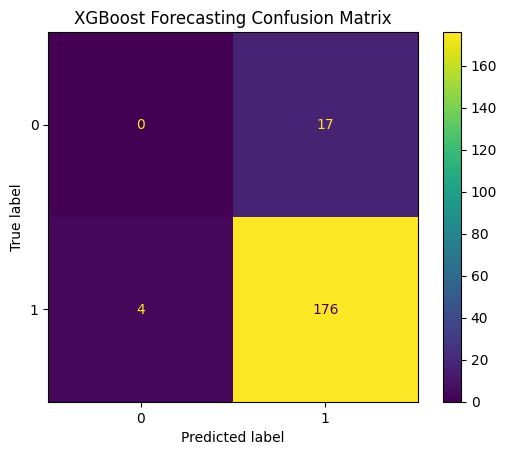

In [48]:
cm_fc = confusion_matrix(y_test_fc, pred_rf_fc)
disp_fc = ConfusionMatrixDisplay(confusion_matrix=cm_fc)
disp_fc.plot()
plt.title("XGBoost Forecasting Confusion Matrix")
plt.show()

In [40]:
df_fc[["Pollution_Level_lag1", "Pollution_Level"]].corr()

,Pollution_Level_lag1,Pollution_Level
Pollution_Level_lag1,1.000000,-0.016383
Pollution_Level,-0.016383,1.000000


In [41]:
model_xgb_fc = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    class_weight="balanced"
)
model_xgb_fc.fit(X_train_fc_sm, y_train_fc_sm)

pred_xgb_fc = model_xgb_fc.predict(X_test_fc)
print(classification_report(y_test_fc, pred_xgb_fc))
importances = pd.Series(model_xgb_fc.feature_importances_, index=X_train_fc.columns)
print(importances.sort_values(ascending=False))

              precision    recall  f1-score   support

           0       0.10      0.18      0.13        17
           1       0.92      0.85      0.88       180

    accuracy                           0.79       197
   macro avg       0.51      0.51      0.50       197
weighted avg       0.85      0.79      0.82       197

Pollution_Level_lag1      0.106950
dayofweek                 0.087940
DO (mg/L)_roll3           0.077460
Mercury (mg/L)_roll3      0.059944
Mercury (mg/L)_lag1       0.056961
BOD (mg/L)_roll3          0.054602
Turbidity (NTU)_lag1      0.054180
Temperature (°C)_lag1     0.052176
hour                      0.051087
Lead (mg/L)_roll3         0.050058
pH_lag1                   0.049530
Lead (mg/L)_lag1          0.048202
Arsenic (mg/L)_lag1       0.047764
Temperature (°C)_roll3    0.040040
DO (mg/L)_lag1            0.039590
BOD (mg/L)_lag1           0.039434
Turbidity (NTU)_roll3     0.032447
pH_roll3                  0.030988
Arsenic (mg/L)_roll3      0.020647
dtype: f

C:\Users\Senzwa4\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [16:09:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


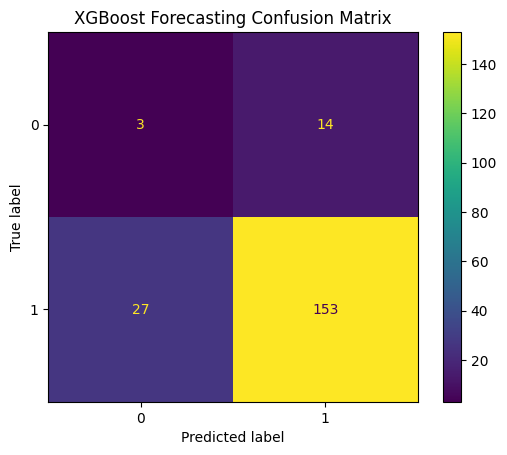

In [42]:
cm_fc = confusion_matrix(y_test_fc, pred_xgb_fc)
disp_fc = ConfusionMatrixDisplay(confusion_matrix=cm_fc)
disp_fc.plot()
plt.title("XGBoost Forecasting Confusion Matrix")
plt.show()

In [43]:
df_fc.groupby("dayofweek")["Pollution_Level"].mean()

dayofweek
0    0.976923
1    0.895105
2    0.916667
3    0.916667
4    0.923611
5    0.923611
6    0.897059
Name: Pollution_Level, dtype: float64

In [44]:
df[df['Pollution_Level']==0]

,Timestamp,Location,pH,Turbidity (NTU),Temperature (°C),DO (mg/L),BOD (mg/L),Lead (mg/L),Mercury (mg/L),Arsenic (mg/L),...,pH_roll3,Turbidity (NTU)_roll3,Temperature (°C)_roll3,DO (mg/L)_roll3,BOD (mg/L)_roll3,Lead (mg/L)_roll3,Mercury (mg/L)_roll3,Arsenic (mg/L)_roll3,hour,dayofweek
1,2024-01-01 23:00:00,L1,6.673190,7.947823,22.140587,5.818803,2.792977,0.009985,0.001422,0.011553,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23,0
3,2024-01-02 09:00:00,L1,7.082763,6.210030,15.583395,3.769910,5.530106,0.010743,0.000816,0.002354,...,7.842605,4.853691,27.322058,4.882740,4.758540,0.009451,0.001117,0.007982,9,1
8,2024-01-03 22:00:00,L1,6.043341,1.341888,25.333968,5.305380,4.203620,0.014671,0.000792,0.004277,...,7.571874,10.810894,21.930501,2.713763,6.246297,0.010150,0.001149,0.012391,22,2
16,2024-01-04 22:00:00,L1,8.027934,2.433973,21.643821,8.019183,3.844912,0.014402,0.000927,0.003435,...,5.922336,11.186596,19.584308,6.837276,5.994902,0.015165,0.000770,0.012405,22,3
18,2024-01-05 05:00:00,L1,8.637175,4.166482,20.649449,8.663438,3.681795,0.006775,0.000017,0.010064,...,6.859673,7.513034,25.783241,7.899423,4.241657,0.012579,0.001148,0.009557,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
929,2024-01-28 12:00:00,L5,7.913344,9.158853,25.007189,7.536404,4.300110,0.012347,0.001219,0.013035,...,7.394869,9.901247,25.024956,6.133904,5.106036,0.009554,0.000871,0.012690,12,6
936,2024-01-29 08:00:00,L5,8.327461,3.047721,34.218403,5.347116,3.964413,0.010391,0.001338,0.002161,...,7.685332,15.533268,30.004422,5.630232,2.439747,0.015265,0.001182,0.013641,8,0
962,2024-02-04 02:00:00,L5,6.665507,6.667268,22.347815,3.988319,4.791708,0.002127,0.000498,0.005045,...,7.298586,8.283480,24.414882,6.454967,5.137180,0.007280,0.001122,0.010031,2,6
974,2024-02-06 23:00:00,L5,8.378682,7.892334,19.738666,4.386180,2.905429,0.006256,0.000970,0.012321,...,7.471636,11.069781,21.819884,7.861076,6.109693,0.007605,0.001325,0.008742,23,1


In [45]:
df_fc.groupby("hour")["Pollution_Level"].mean()

hour
0     0.875000
1     0.902439
2     0.926829
3     0.878049
4     0.902439
5     0.926829
6     0.951220
7     0.951220
8     0.880952
9     0.880952
10    0.951220
11    0.976190
12    0.904762
13    0.902439
14    0.975610
15    1.000000
16    0.951220
17    0.951220
18    0.875000
19    0.926829
20    0.926829
21    0.951220
22    0.853659
23    0.875000
Name: Pollution_Level, dtype: float64

From here we save the xgb forecasting model into a joblib and the features that will be needed by the model

In [46]:
import joblib

joblib.dump(model_xgb_fc, "xgb_forecast_model.joblib")

# Save the exact feature order the forecasting model expects
feature_columns_fc = list(X_fc.columns)
joblib.dump(feature_columns_fc, "feature_columns_fc.joblib")

print("Saved forecasting model and feature columns.")

Saved forecasting model and feature columns.


Then here we create the app.py file to that we can use streamlit to run it 

In [47]:
app_code = '''
"""
Water Quality Pollution Level Predictor - Streamlit App
----------------------------------------------------------
A simple web app that takes a single set of water-quality readings
and predicts whether the water is "Polluted" or "Not Polluted",
using the model trained by train_model.py.

Run with:
    streamlit run app.py
"""

import os
import streamlit as st
import pandas as pd
import joblib

BASE_DIR = os.path.dirname(os.path.abspath(__file__))
MODEL_PATH = os.path.join(BASE_DIR, "pollution_model.joblib")
FEATURE_COLUMNS_PATH = os.path.join(BASE_DIR, "feature_columns.joblib")

st.set_page_config(page_title="Water Pollution Predictor", page_icon="💧")


@st.cache_resource
def load_model():
    model = joblib.load(MODEL_PATH)
    feature_columns = joblib.load(FEATURE_COLUMNS_PATH)
    return model, feature_columns


model, feature_columns = load_model()

st.title("💧 Water Pollution Level Predictor")
st.write(
    "Enter a water-quality reading below to predict whether the water "
    "sample is **Polluted** or **Not Polluted**."
)

st.subheader("Water Quality Reading")

col1, col2 = st.columns(2)

with col1:
    pH = st.number_input("pH", min_value=0.0, max_value=14.0, value=7.25, step=0.01)
    turbidity = st.number_input(
        "Turbidity (NTU)", min_value=0.0, max_value=50.0, value=10.2, step=0.1
    )
    temperature = st.number_input(
        "Temperature (°C)", min_value=0.0, max_value=50.0, value=25.0, step=0.1
    )
    do = st.number_input(
        "Dissolved Oxygen - DO (mg/L)", min_value=0.0, max_value=20.0, value=5.9, step=0.1
    )

with col2:
    bod = st.number_input(
        "BOD (mg/L)", min_value=0.0, max_value=20.0, value=5.5, step=0.1
    )
    lead = st.number_input(
        "Lead (mg/L)", min_value=0.0, max_value=0.05, value=0.01, step=0.001, format="%.4f"
    )
    mercury = st.number_input(
        "Mercury (mg/L)", min_value=0.0, max_value=0.01, value=0.001, step=0.0001, format="%.5f"
    )
    arsenic = st.number_input(
        "Arsenic (mg/L)", min_value=0.0, max_value=0.05, value=0.01, step=0.001, format="%.4f"
    )

if st.button("Predict Pollution Level", type="primary"):
    input_row = pd.DataFrame(
        [[pH, turbidity, temperature, do, bod, lead, mercury, arsenic]],
        columns=feature_columns,
    )

    prediction = model.predict(input_row)[0]
    label = "🔴 Polluted" if prediction == 1 else "🟢 Not Polluted"

    st.subheader("Result")
    if prediction == 1:
        st.error(f"Prediction: {label}")
    else:
        st.success(f"Prediction: {label}")

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(input_row)[0]
        proba_df = pd.DataFrame(
            {
                "Pollution Level": ["Not Polluted", "Polluted"],
                "Probability": proba,
            }
        ).set_index("Pollution Level")
        st.bar_chart(proba_df)

st.caption(
    "Model: XGBoost classifier trained on historical water-quality readings "
    "(pH, turbidity, temperature, dissolved oxygen, BOD, lead, mercury, arsenic)."
)
st.subheader("What drives the model's predictions")
importance_df = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": model.feature_importances_,
}).sort_values("Importance", ascending=True)
st.bar_chart(importance_df.set_index("Feature"))



st.subheader("Your reading vs. typical values")

# Class averages from the training data (Water_Quality_Dataset.csv)
class_averages = pd.DataFrame({
    "Not Polluted (avg)": [7.29, 5.30, 25.57, 6.68, 3.64, 0.0076, 0.0008, 0.0077],
    "Polluted (avg)":     [7.25, 10.64, 24.92, 5.86, 5.64, 0.0102, 0.0010, 0.0100],
    "Your Reading":       [pH, turbidity, temperature, do, bod, lead, mercury, arsenic],
}, index=feature_columns)

st.dataframe(class_averages.style.format("{:.4f}"))

# Turbidity and BOD are the two strongest signals — chart those specifically
comparison_chart = class_averages.loc[["Turbidity (NTU)", "BOD (mg/L)"]].T
st.bar_chart(comparison_chart)

'''

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("app.py created.")

app.py created.


The final classification model — an XGBoost classifier trained on pH, Turbidity, Temperature, DO, BOD, Lead, Mercury, and Arsenic, with SMOTE used to correct the class imbalance in training — reliably predicts pollution level from a single water-quality reading, achieving ~99% accuracy on the held-out test set with strong precision and recall on both classes (Not Polluted and Polluted), and the correlation and class-mean analysis confirm this isn't a fluke: Turbidity and BOD genuinely differ meaningfully between the two classes and are the model's strongest signals. Forecasting future pollution from only past readings was investigated separately but was found not to be viable with this dataset — lag correlation, feature importance, and calendar-based tests all showed no exploitable temporal signal — so that direction was correctly dropped rather than shipped as an unreliable feature.